Saving failure_parallel.csv to failure_parallel.csv
Saving failure_perpendicular.csv to failure_perpendicular.csv
Saving failure_sample3.csv to failure_sample3.csv
Saving failure_sample4.csv to failure_sample4.csv
Saving preload_parallel.csv to preload_parallel.csv
Saving preload_perpendicular.csv to preload_perpendicular.csv
Saving preload_sample3.csv to preload_sample3.csv
Saving preload_sample4.csv to preload_sample4.csv
The data from failure_parallel.csv has 647 rows and 4 columns.
The data from failure_perpendicular.csv has 126 rows and 4 columns.
The data from failure_sample3.csv has 135 rows and 4 columns.
The data from failure_sample4.csv has 126 rows and 4 columns.


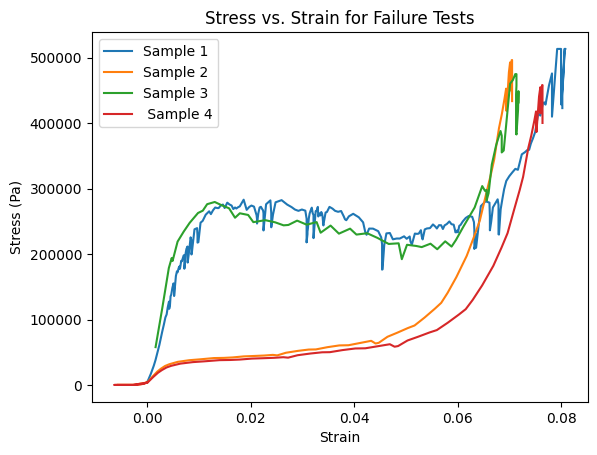

Percent change in volume for parallel specimen 1: -39.24%
Percent change in volume for perpendicular specimen 1: -41.67%
Percent change in volume for parallel specimen 2 (sample 3): -52.78%
Percent change in volume for perpendicular specimen 2 (sample 4): -41.67%

Material Properties:
Young's Modulus for parallel specimen 1: 2.78e+07 Pa
Yield Stress for parallel specimen 1: 3.40e+03 Pa
Young's Modulus for perpendicular specimen 1: 6.17e+05 Pa
Yield Stress for perpendicular specimen 1: 4.58e+03 Pa
Young's Modulus for parallel specimen 2 (sample 3): 1.50e+07 Pa
Yield Stress for parallel specimen 2 (sample 3): 5.79e+04 Pa
Young's Modulus for perpendicular specimen 2 (sample 4): 5.26e+05 Pa
Yield Stress for perpendicular specimen 2 (sample 4):4.23e+03 Pa

Densities:
Density for parallel specimen 1: 0.3472 g/cm³
Density for perpendicular specimen 1: 0.4051 g/cm³
Density for parallel specimen 2: 0.3803 g/cm³
Density for perpendicular specimen 2 (sample 4): 0.4630 g/cm³


In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import io
from google.colab import files

# Step 1: Upload your data files
uploaded = files.upload()

# Step 2: Load the data into numpy arrays
data_files = {}
for filename in uploaded.keys():
    data_files[filename] = np.genfromtxt(io.BytesIO(uploaded[filename]), delimiter=',', skip_header=1)

# Step 3: Identify and process the preload and failure files
preload_parallel_filename = None
preload_perpendicular_filename = None
failure_parallel_filename = None
failure_perpendicular_filename = None
preload_sample3_filename = None
preload_sample4_filename = None
failure_sample3_filename = None
failure_sample4_filename = None

for filename in data_files.keys():
    if 'preload_parallel' in filename.lower():
        preload_parallel_filename = filename
    elif 'preload_perpendicular' in filename.lower():
        preload_perpendicular_filename = filename
    elif 'failure_parallel' in filename.lower():
        failure_parallel_filename = filename
    elif 'failure_perpendicular' in filename.lower():
        failure_perpendicular_filename = filename
    elif 'preload_sample3' in filename.lower():
        preload_sample3_filename = filename
    elif 'preload_sample4' in filename.lower():
        preload_sample4_filename = filename
    elif 'failure_sample3' in filename.lower():
        failure_sample3_filename = filename
    elif 'failure_sample4' in filename.lower():
        failure_sample4_filename = filename

# Function to process preload data and extract preload value
def get_preload_value(filename):
    data = data_files[filename]
    force_run = data[:, 2]  # Force
    force_run_noNaN = force_run[~np.isnan(force_run)]
    preload_val = force_run_noNaN[-1]  # Extract the preload value
    return preload_val

# Function to process and plot failure data with preload adjustment
def process_and_plot_failure(filename, preload_val, label, initial_length, initial_area):
    data = data_files[filename]

    # Inspect the shape of the data
    data_shape = np.shape(data)
    print(f"The data from {filename} has {data_shape[0]} rows and {data_shape[1]} columns.")

    # Slice the data to isolate specific runs
    time_run = data[:, 0]  # Time
    position_run = data[:, 1]  # Position
    force_run = data[:, 2]  # Force

    # Remove NaN values from the data
    position_run_noNaN = position_run[~np.isnan(position_run)]
    force_run_noNaN = force_run[~np.isnan(force_run)]

    # Adjust the force data using the preload value
    force_run_noNaN += preload_val

    # Calculate stress and strain
    strain = position_run_noNaN / initial_length
    stress = force_run_noNaN / initial_area

    # Plot Stress vs. Strain
    plt.plot(strain, stress, label=label)

    # Return stress and strain for further calculations
    return strain, stress

# Step 4: Process preload files to get preload values
preload_parallel_val = get_preload_value(preload_parallel_filename) if preload_parallel_filename else 0
preload_perpendicular_val = get_preload_value(preload_perpendicular_filename) if preload_perpendicular_filename else 0
preload_sample3_val = get_preload_value(preload_sample3_filename) if preload_sample3_filename else 0
preload_sample4_val = get_preload_value(preload_sample4_filename) if preload_sample4_filename else 0

# Step 5: Process and plot failure files with preload adjustment
plt.figure()

# Initial dimensions for parallel and perpendicular specimens (length, width, height in meters)
initial_length_parallel = 0.12  # Initial length for parallel specimen
initial_area_parallel = 0.12 * 0.12  # Initial cross-sectional area for parallel specimen
initial_length_perpendicular = 0.13  # Initial length for perpendicular specimen
initial_area_perpendicular = 0.12 * 0.12  # Initial cross-sectional area for perpendicular specimen
initial_length_sample3 = 0.13  # Initial length for sample 3 (parallel)
initial_area_sample3 = 0.13 * 0.12  # Initial cross-sectional area for sample 3 (parallel)
initial_length_sample4 = 0.12  # Initial length for sample 4 (perpendicular)
initial_area_sample4 = 0.12 * 0.13  # Initial cross-sectional area for sample 4 (perpendicular)

strain_parallel, stress_parallel = process_and_plot_failure(
    failure_parallel_filename, preload_parallel_val, 'Sample 1', initial_length_parallel, initial_area_parallel
) if failure_parallel_filename else (None, None)

strain_perpendicular, stress_perpendicular = process_and_plot_failure(
    failure_perpendicular_filename, preload_perpendicular_val, 'Sample 2', initial_length_perpendicular, initial_area_perpendicular
) if failure_perpendicular_filename else (None, None)

strain_sample3, stress_sample3 = process_and_plot_failure(
    failure_sample3_filename, preload_sample3_val, 'Sample 3', initial_length_sample3, initial_area_sample3
) if failure_sample3_filename else (None, None)

strain_sample4, stress_sample4 = process_and_plot_failure(
    failure_sample4_filename, preload_sample4_val, ' Sample 4', initial_length_sample4, initial_area_sample4
) if failure_sample4_filename else (None, None)

# Customize the plot
plt.title('Stress vs. Strain for Failure Tests')
plt.xlabel('Strain')
plt.ylabel('Stress (Pa)')
plt.legend()
plt.show()

# Step 6: Calculate percent change in volume
def calculate_volume_change(initial_dims, final_dims):
    initial_volume = np.prod(initial_dims)
    final_volume = np.prod(final_dims)
    percent_change = ((final_volume - initial_volume) / initial_volume) * 100
    return percent_change

# Example initial and final dimensions (length, width, height in meters)
initial_dims_parallel = [0.12, 0.12, 0.12]  # Initial dimensions for parallel specimen
final_dims_parallel = [0.14, 0.05, 0.15]  # Final dimensions for parallel specimen
initial_dims_perpendicular = [0.13, 0.12, 0.12]  # Initial dimensions for perpendicular specimen
final_dims_perpendicular = [0.13, 0.07, 0.12]  # Final dimensions for perpendicular specimen
initial_dims_sample3 = [0.13, 0.12, 0.12]  # Initial dimensions for sample 3 (parallel)
final_dims_sample3 = [0.17, 0.04, 0.13]  # Final dimensions for sample 3 (parallel)
initial_dims_sample4 = [0.13, 0.12, 0.12]  # Initial dimensions for sample 4 (perpendicular)
final_dims_sample4 = [0.13, 0.07, 0.12]  # Final dimensions for sample 4 (perpendicular)

percent_change_parallel = calculate_volume_change(initial_dims_parallel, final_dims_parallel)
percent_change_perpendicular = calculate_volume_change(initial_dims_perpendicular, final_dims_perpendicular)
percent_change_sample3 = calculate_volume_change(initial_dims_sample3, final_dims_sample3)
percent_change_sample4 = calculate_volume_change(initial_dims_sample4, final_dims_sample4)

print(f"Percent change in volume for parallel specimen 1: {percent_change_parallel:.2f}%")
print(f"Percent change in volume for perpendicular specimen 1: {percent_change_perpendicular:.2f}%")
print(f"Percent change in volume for parallel specimen 2 (sample 3): {percent_change_sample3:.2f}%")
print(f"Percent change in volume for perpendicular specimen 2 (sample 4): {percent_change_sample4:.2f}%")

# Step 7: Calculate density, Young's Modulus (E), and yield stress (σy)
def calculate_material_properties(strain, stress):
    if len(strain) < 2:
        print("Not enough data points to calculate material properties.")
        return None, None
    # Calculate Young's Modulus (E) as the slope of the initial linear portion of the stress-strain curve
    # Here, we'll take the first 10% of the data points to estimate E
    num_points = max(int(0.1 * len(strain)), 2)  # Ensure at least two points
    E, _ = np.polyfit(strain[:num_points], stress[:num_points], 1)

    # Calculate yield stress (σy) using the 0.2% offset method
    offset = 0.002  # 0.2% strain offset
    # Create a line with slope E and offset strain
    offset_line = E * (strain - offset)

    # Find the intersection point between the stress-strain curve and the offset line
    intersection_indices = np.where(stress >= offset_line)[0]
    if len(intersection_indices) == 0:
        yield_stress = max(stress)
    else:
        first_intersection = intersection_indices[0]
        yield_stress = stress[first_intersection]

    return E, yield_stress

E_parallel, yield_stress_parallel = calculate_material_properties(strain_parallel, stress_parallel) if strain_parallel is not None else (None, None)
E_perpendicular, yield_stress_perpendicular = calculate_material_properties(strain_perpendicular, stress_perpendicular) if strain_perpendicular is not None else (None, None)
E_sample3, yield_stress_sample3 = calculate_material_properties(strain_sample3, stress_sample3) if strain_sample3 is not None else (None, None)
E_sample4, yield_stress_sample4 = calculate_material_properties(strain_sample4, stress_sample4) if strain_sample4 is not None else (None, None)

# Example densities (in grams per cubic centimeter)
density_parallel = 0.34722222222222  # Density for parallel specimen
density_perpendicular = 0.40509259259259  # Density for perpendicular specimen
density_sample3 = 0.38026944806606  # Density for sample 3 (parallel)
density_sample4 = 0.46296296296296  # Density for sample 4 (perpendicular)

# Print Young's Modulus and Yield Stress
print("\nMaterial Properties:")
if E_parallel is not None:
    print(f"Young's Modulus for parallel specimen 1: {E_parallel:.2e} Pa")
    print(f"Yield Stress for parallel specimen 1: {yield_stress_parallel:.2e} Pa")
else:
    print("Parallel specimen: E and Yield Stress not available.")

if E_perpendicular is not None:
    print(f"Young's Modulus for perpendicular specimen 1: {E_perpendicular:.2e} Pa")
    print(f"Yield Stress for perpendicular specimen 1: {yield_stress_perpendicular:.2e} Pa")
else:
    print("Perpendicular specimen: E and Yield Stress not available.")

if E_sample3 is not None:
    print(f"Young's Modulus for parallel specimen 2 (sample 3): {E_sample3:.2e} Pa")
    print(f"Yield Stress for parallel specimen 2 (sample 3): {yield_stress_sample3:.2e} Pa")
else:
    print("Sample 3 (parallel): E and Yield Stress not available.")

if E_sample4 is not None:
    print(f"Young's Modulus for perpendicular specimen 2 (sample 4): {E_sample4:.2e} Pa")
    print(f"Yield Stress for perpendicular specimen 2 (sample 4):{yield_stress_sample4:.2e} Pa")
else:
    print("Sample 4 (perpendicular): E and Yield Stress not available.")

# Optionally, print densities if needed
print("\nDensities:")
print(f"Density for parallel specimen 1: {density_parallel:.4f} g/cm³")
print(f"Density for perpendicular specimen 1: {density_perpendicular:.4f} g/cm³")
print(f"Density for parallel specimen 2: {density_sample3:.4f} g/cm³")
print(f"Density for perpendicular specimen 2 (sample 4): {density_sample4:.4f} g/cm³")
